<a href="https://colab.research.google.com/github/Steyn555247/CIS5200-Fall-2025/blob/Homework-5-10%2F19/HW5_10_19_SteynKnollema.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIS 5200: Machine Learning
## Homework 5

**Dataset Creation**
We’ll start by generating a synthetic dataset based on real lending club patterns. The data includes features like credit score, income, debt-to-income ratio, and loan amount.

**Takeaway**: Real lending data is complex and noisy — simple models struggle with subtle patterns!

**Part 1**: Shallow Decision Tree

Here you'll train a shallow decision tree to predict loan defaults.

**Takeaway**: Individual trees are interpretable but limited — they miss complex feature interactions and overfit to noise.

**Part 2**: Random Forest Ensemble

Now you'll trian a random forest ensemble using scikit-learn and fine tune the hyperparameter to check the accuracy.

**Takeaway**: Ensembles reduce overfitting through averaging and capture complex patterns through diversity.

**Analysis of Model**: Finally, you'll analyze from bias-varaiance decompostion perspective to check our model's performance.

**Big Picture**: This homework demonstrates how ensemble methods transform weak learners into strong predictors.
The "wisdom of crowds" principle: many diverse, moderately-informed opinions beat one expert opinion.

### Import Libraries

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## Create the Dataset
**You don't need to modify anything, this is data creation steps, just run below cells.**

## Target Variable (Labels):
0 = Loan was fully paid back (No Default)

1 = Loan defaulted/charged off (Default)

## Features Generated and Their Business Impact:

### 1. Core Financial Features:
- credit_score (300-850): FICO credit score reflecting borrower's credit history
- annual_income ($25k-$300k): Borrower's yearly income (log-normal distribution)  
- loan_amount ($1k-$40k): Amount requested, correlated with income but with noise
- dti (0.01-0.45): Debt-to-income ratio, key indicator of financial stress

### 2. Credit Behavior Features:
- emp_length (0-20 years): Employment stability indicator
- inq_last_6mths (0-10): Recent credit inquiries (sign of credit seeking)
- open_acc (1-25): Number of open credit accounts
- revol_util (0-1): Credit utilization rate (how much of available credit is used)


## Machine Learning Challenge:
Our models must learn complex, non-linear relationships:
- Shallow Tree: Limited to simple rules (≤4 levels)
- Random Forest: Can capture intricate feature interactions through ensemble


In [36]:
# Generate 10,000 loan applications
n_samples = 10000

# Create realistic feature distributions based on Lending Club patterns
def create_lending_data(n_samples):
    data = {}

    # Credit Score (300-850, normally distributed around 680)
    data['credit_score'] = np.random.normal(680, 80, n_samples)
    data['credit_score'] = np.clip(data['credit_score'], 300, 850)

    # Annual Income (log-normal distribution, $30k-$200k typical range)
    data['annual_income'] = np.random.lognormal(10.8, 0.6, n_samples)
    data['annual_income'] = np.clip(data['annual_income'], 25000, 300000)

    # Loan Amount (related to income but with noise)
    income_factor = data['annual_income'] / 100000  # Scale factor
    data['loan_amount'] = (np.random.normal(0.15, 0.08, n_samples) * data['annual_income'] +
                          np.random.normal(0, 5000, n_samples))
    data['loan_amount'] = np.clip(data['loan_amount'], 1000, 40000)

    # Debt-to-Income Ratio
    existing_debt = np.random.exponential(0.15, n_samples) * data['annual_income']
    data['dti'] = (existing_debt + data['loan_amount'] * 0.1) / data['annual_income']
    data['dti'] = np.clip(data['dti'], 0.01, 0.45)

    # Employment Length (years, 0-20)
    data['emp_length'] = np.random.exponential(5, n_samples)
    data['emp_length'] = np.clip(data['emp_length'], 0, 20)

    # Number of Credit Inquiries (last 6 months)
    data['inq_last_6mths'] = np.random.poisson(1.2, n_samples)
    data['inq_last_6mths'] = np.clip(data['inq_last_6mths'], 0, 10)

    # Number of Open Credit Lines
    data['open_acc'] = np.random.poisson(8, n_samples)
    data['open_acc'] = np.clip(data['open_acc'], 1, 25)

    # Total Credit Utilization
    data['revol_util'] = np.random.beta(2, 3, n_samples)  # Skewed toward lower utilization

    return data

# Generate the data
loan_data = create_lending_data(n_samples)
df = pd.DataFrame(loan_data)

In [37]:
# Default probability based on realistic lending patterns
# Low credit score + high DTI + recent inquiries = High default probability
# High credit score + stable employment + low utilization = Low default probability
def calculate_default_probability(row):
    # Base probability
    prob = 0.15

    # Credit score impact (strongest predictor)
    if row['credit_score'] < 600:
        prob *= 3.5
    elif row['credit_score'] < 650:
        prob *= 2.2
    elif row['credit_score'] > 750:
        prob *= 0.4

    # DTI impact
    if row['dti'] > 0.35:
        prob *= 2.0
    elif row['dti'] > 0.25:
        prob *= 1.5

    # Income impact (lower income = higher risk)
    if row['annual_income'] < 40000:
        prob *= 1.8
    elif row['annual_income'] > 100000:
        prob *= 0.7

    # Recent inquiries (sign of credit seeking)
    if row['inq_last_6mths'] > 3:
        prob *= 1.6

    # High utilization
    if row['revol_util'] > 0.8:
        prob *= 1.4

    # Employment stability
    if row['emp_length'] < 1:
        prob *= 1.3
    elif row['emp_length'] > 10:
        prob *= 0.8

    return min(prob, 0.9)  # Cap at 90%

# Apply default probability and generate binary outcomes
df['default_prob'] = df.apply(calculate_default_probability, axis=1)
# New deterministic line
default_threshold = 0.25
df['default'] = (df['default_prob'] > default_threshold).astype(int)
#df['default'] = np.random.binomial(1, df['default_prob'], n_samples)
# Re-introduce controlled noise for a more realistic problem
# We will randomly flip 10% of the labels to create irreducible error.
noise_level = 0.10
n_labels_to_flip = int(noise_level * n_samples)
flip_indices = np.random.choice(df.index, size=n_labels_to_flip, replace=False)

# Flip the selected labels (0 becomes 1, 1 becomes 0)
df.loc[flip_indices, 'default'] = 1 - df.loc[flip_indices, 'default']

print(f"Dataset created with {len(df):,} loans")
print(f"Default rate: {df['default'].mean():.1%}")
print(f"Features: {list(df.columns[:-2])}")  # Exclude default_prob and default

# Display summary statistics
print("\nDataset Summary:")
print(df.describe())


Dataset created with 10,000 loans
Default rate: 52.9%
Features: ['credit_score', 'annual_income', 'loan_amount', 'dti', 'emp_length', 'inq_last_6mths', 'open_acc', 'revol_util']

Dataset Summary:
       credit_score  annual_income   loan_amount           dti    emp_length  \
count  10000.000000   10000.000000  10000.000000  10000.000000  10000.000000   
mean     678.177116   59834.892393   9600.680652      0.159634      4.840876   
std       77.914524   37026.543846   8257.773268      0.124174      4.576090   
min      407.338477   25000.000000   1000.000000      0.010000      0.000183   
25%      624.757989   33397.209500   3017.979302      0.061126      1.416159   
50%      679.516311   49513.692144   7812.876210      0.121994      3.417998   
75%      731.936352   74288.610473  13601.030808      0.228725      6.795178   
max      850.000000  300000.000000  40000.000000      0.450000     20.000000   

       inq_last_6mths      open_acc    revol_util  default_prob       default  
cou

In [38]:
# Add any code you'd like for data visualizations
# Select features (exclude default_prob as it's not available in real scenarios)
feature_columns = ['credit_score', 'annual_income', 'loan_amount', 'dti',
                   'emp_length', 'inq_last_6mths', 'open_acc', 'revol_util']

X = df[feature_columns].values
y = df['default'].values

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")
print(f"Training default rate: {y_train.mean():.1%}")
print(f"Test default rate: {y_test.mean():.1%}")

Training set: 7,000 samples
Test set: 3,000 samples
Training default rate: 52.9%
Test default rate: 52.9%


/tmp/ipython-input-1865104452.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_credit = df.groupby(credit_bins)['default'].mean() * 100
/tmp/ipython-input-1865104452.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_dti = df.groupby(dti_bins)['default'].mean() * 100
/tmp/ipython-input-1865104452.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_income = df.groupby(income_bins)['

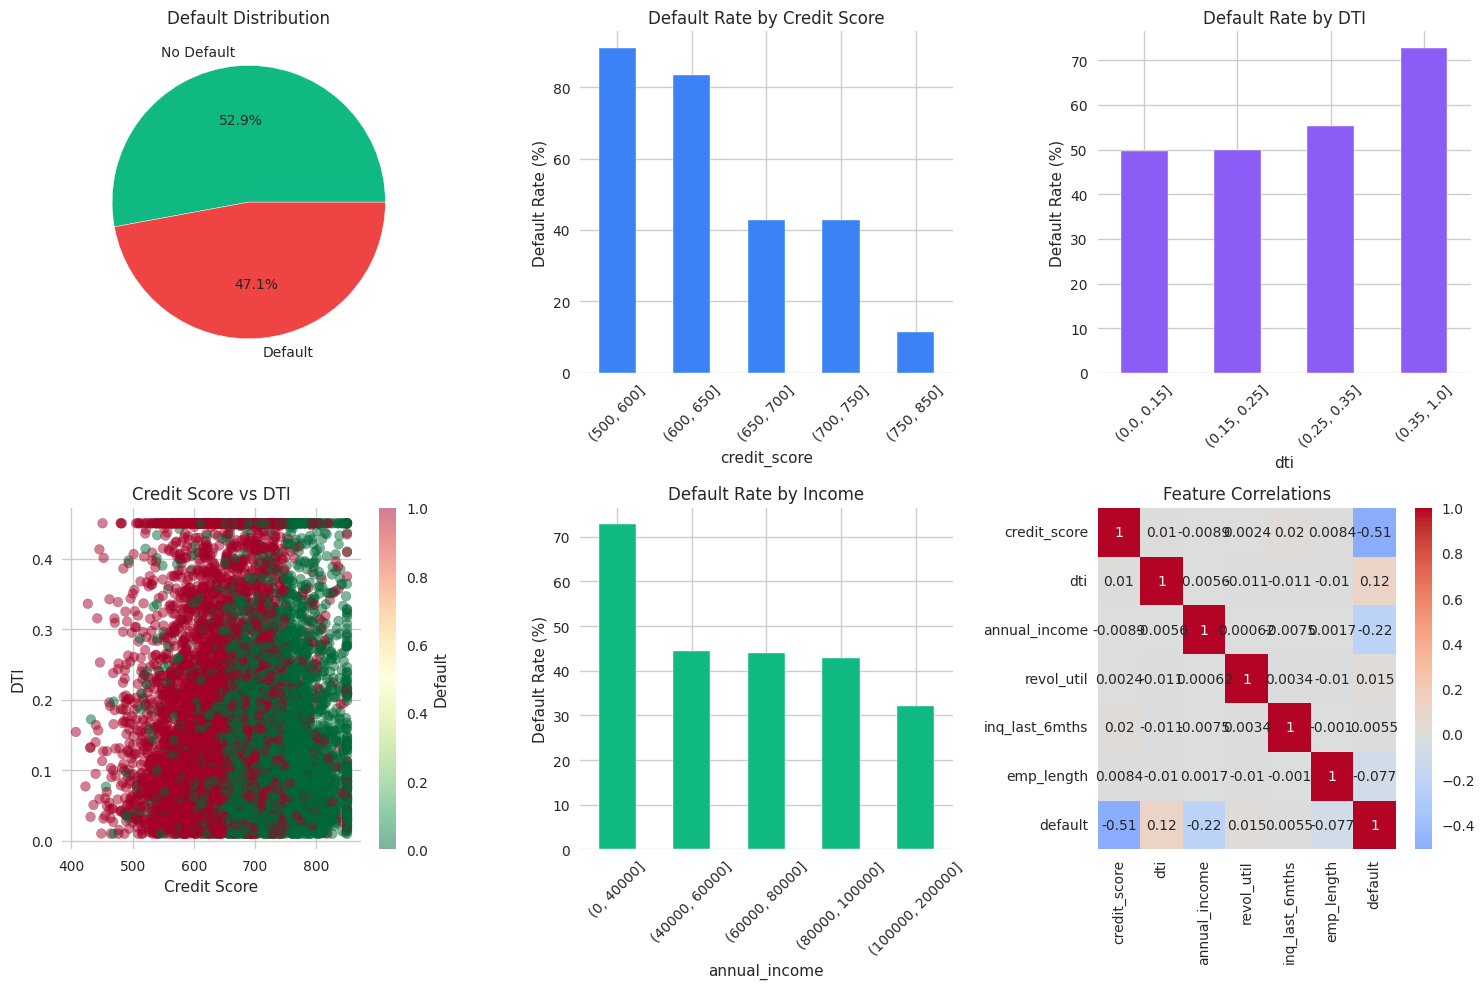

In [39]:


# Set style
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Default distribution
axes[0, 0].pie(df['default'].value_counts(), labels=['No Default', 'Default'],
               autopct='%1.1f%%', colors=['#10b981', '#ef4444'])
axes[0, 0].set_title('Default Distribution')

# 2. Default rate by credit score bins
credit_bins = pd.cut(df['credit_score'], bins=[500, 600, 650, 700, 750, 850])
default_by_credit = df.groupby(credit_bins)['default'].mean() * 100
default_by_credit.plot(kind='bar', ax=axes[0, 1], color='#3b82f6')
axes[0, 1].set_title('Default Rate by Credit Score')
axes[0, 1].set_ylabel('Default Rate (%)')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Default rate by DTI bins
dti_bins = pd.cut(df['dti'], bins=[0, 0.15, 0.25, 0.35, 1.0])
default_by_dti = df.groupby(dti_bins)['default'].mean() * 100
default_by_dti.plot(kind='bar', ax=axes[0, 2], color='#8b5cf6')
axes[0, 2].set_title('Default Rate by DTI')
axes[0, 2].set_ylabel('Default Rate (%)')
axes[0, 2].tick_params(axis='x', rotation=45)

# 4. Scatter: Credit Score vs DTI
scatter = axes[1, 0].scatter(df['credit_score'], df['dti'],
                             c=df['default'], cmap='RdYlGn_r', alpha=0.5)
axes[1, 0].set_xlabel('Credit Score')
axes[1, 0].set_ylabel('DTI')
axes[1, 0].set_title('Credit Score vs DTI')
plt.colorbar(scatter, ax=axes[1, 0], label='Default')

# 5. Default rate by income bins
income_bins = pd.cut(df['annual_income'], bins=[0, 40000, 60000, 80000, 100000, 200000])
default_by_income = df.groupby(income_bins)['default'].mean() * 100
default_by_income.plot(kind='bar', ax=axes[1, 1], color='#10b981')
axes[1, 1].set_title('Default Rate by Income')
axes[1, 1].set_ylabel('Default Rate (%)')
axes[1, 1].tick_params(axis='x', rotation=45)

# 6. Correlation heatmap
corr_cols = ['credit_score', 'dti', 'annual_income', 'revol_util', 'inq_last_6mths', 'emp_length', 'default']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', center=0, ax=axes[1, 2])
axes[1, 2].set_title('Feature Correlations')

plt.tight_layout()
plt.show()

### PART 1: Shallow Decision Tree
You will implement the following two functions:
- calculate_entropy (2 points)
- calculate_information_gain (2 points)

**You only need the above two functions to get scores!!

Information gain basically tells you how much knowledge we gain from splitting the data; it is as a measure to evaluate the split.

Decision trees need to decide:

Which feature to split on? (credit_score? income? dti?)

What threshold to use? (credit_score <= 650?)

Information gain helps us pick the best split that separates defaults from non-defaults most effectively.

The below functions show you how to build a naive decision tree from scratch!


In [40]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split

class Node:
    """A node in our decision tree"""
    # Using a more robust __init__ for clarity
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, prediction=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.prediction = prediction # Used for leaf nodes

    def is_leaf(self):
        return self.prediction is not None

def calculate_entropy(y):
    """
    Calculate entropy of target variable.
    Entropy formula: -Σ(p_i * log2(p_i))
    where p_i is proportion of class i
    """
    # Step 1: Handle edge case - if empty, return 0
    if len(y) == 0:
        return 0

    ###################TO DO ############################
    # Step 2: Count occurrences of each class (0 and 1)
    class_counts = np.bincount(y)

    # Step 3: Calculate probabilities for each class
    probabilities = class_counts/len(y)

    # Step 4: Calculate entropy using formula: -Σ(p_i * log2(p_i))
    entropy = -np.sum(np.where(probabilities>0, probabilities *np.log2(probabilities), 0))
    ######################################################
    return entropy

def calculate_gini(y):
    """Calculates the Gini impurity for a set of labels."""
    if len(y) == 0:
        return 0
    class_counts = np.bincount(y)
    probabilities = class_counts / len(y)
    gini = 1 - np.sum(probabilities ** 2)
    return gini

def calculate_information_gain(parent_y, left_y, right_y, criterion='entropy'):
    """
    Calculate information gain from a split.
    Information Gain = Parent_Impurity - Weighted_Average_Child_Impurity
    """
    # Step 1: Calculate parent impurity
    if criterion == 'entropy':
        #####################TO DO ########################
        parent_impurity = calculate_entropy(parent_y) #call the function above to get entropy for parent_y
        ###################################################
    else:
        parent_impurity = calculate_gini(parent_y)

    # Step 2: Calculate weighted average of children impurities
    n_total = len(parent_y)
    n_left = len(left_y)
    n_right = len(right_y)

    if n_total == 0 or n_left == 0 or n_right == 0:
        return 0

    #####################TO DO ########################
    # TODO: Calculate left and right impurities
    # call the function above to get entropy for left and right
    if criterion == 'entropy':
        left_impurity = calculate_entropy(left_y)
        right_impurity = calculate_entropy(right_y)
    ###################################################
    else:
        left_impurity = calculate_gini(left_y)
        right_impurity = calculate_gini(right_y)

    #####################TO DO ########################
    # Step 3: Calculate weighted average
    weighted_avg = n_left/n_total * left_impurity + n_right/n_total * right_impurity       # hint: weight1 * left_impurity + weight2 * right_impurity

    # Step 4: Calculate information gain
    gain = parent_impurity - weighted_avg      # hint: Parent impurity - weighted average
    ###################################################
    return gain

def find_best_split(X, y, min_samples_leaf=10):
    """
    Finds the best feature and threshold by searching all unique values.
    Works with NumPy arrays.
    """
    best_gain = 0
    best_feature_idx = None
    best_threshold = None
    n_samples, n_features = X.shape

    # Ensure y is a numpy array for boolean indexing
    y = np.array(y)

    for feature_idx in range(n_features):
        feature_values = X[:, feature_idx]
        thresholds = np.unique(feature_values)

        for threshold in thresholds:
            left_mask = feature_values <= threshold
            right_mask = ~left_mask

            # Ensure the split is not trivial
            if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                continue

            left_y, right_y = y[left_mask], y[right_mask]

            if len(left_y) < min_samples_leaf or len(right_y) < min_samples_leaf:
                continue

            gain = calculate_information_gain(y, left_y, right_y, criterion='gini')

            if gain > best_gain:
                best_gain = gain
                best_feature_idx = feature_idx
                best_threshold = threshold

    return best_feature_idx, best_threshold

def build_tree(X, y, depth=0, max_depth=3, min_samples_split=2, min_samples_leaf=1):
    """Recursively builds the decision tree using NumPy arrays."""
    n_samples = len(y)

    # Stopping criteria
    if (depth >= max_depth or
        len(np.unique(y)) == 1 or
        n_samples < min_samples_split):
        leaf_prediction = np.bincount(y).argmax()
        return Node(prediction=leaf_prediction)

    best_feature, best_threshold = find_best_split(X, y, min_samples_leaf)

    # If no effective split is found, create a leaf
    if best_feature is None:
        leaf_prediction = np.bincount(y).argmax()
        return Node(prediction=leaf_prediction)

    # Split data and build children
    left_mask = X[:, best_feature] <= best_threshold
    right_mask = ~left_mask

    left_child = build_tree(X[left_mask], y[left_mask], depth + 1, max_depth, min_samples_split, min_samples_leaf)
    right_child = build_tree(X[right_mask], y[right_mask], depth + 1, max_depth, min_samples_split, min_samples_leaf)

    return Node(feature=best_feature, threshold=best_threshold, left=left_child, right=right_child)

def predict_sample(node, sample):
    """Predicts a single sample (NumPy array) by traversing the tree."""
    if node.is_leaf():
        return node.prediction

    # Use integer index for feature
    if sample[node.feature] <= node.threshold:
        return predict_sample(node.left, sample)
    else:
        return predict_sample(node.right, sample)

def get_accuracy(tree, X, y):
    """Calculates the accuracy of the tree on a NumPy dataset."""
    # No .iterrows(), just iterate through the rows of the NumPy array
    predictions = [predict_sample(tree, sample) for sample in X]
    return np.mean(predictions == y)


In [41]:
# =============================================================================
# TEST THE IMPLEMENTATION
# =============================================================================

# Test entropy calculation
print("Testing entropy calculation...")
test_y = np.array([0, 0, 0, 1, 1])  # 3 zeros, 2 ones
expected_entropy = -((3/5) * np.log2(3/5) + (2/5) * np.log2(2/5))
your_entropy = calculate_entropy(test_y)
print(f"Expected entropy: {expected_entropy:.4f}")
print(f"Your entropy: {your_entropy:.4f}")
print(f"✅ Correct!" if abs(your_entropy - expected_entropy) < 0.001 else "❌ Check your entropy implementation")


# Test information gain
print("\nTesting information gain...")
parent_y = np.array([0, 0, 1, 1, 1, 1])
left_y = np.array([0, 0])
right_y = np.array([1, 1, 1, 1])
gain = calculate_information_gain(parent_y, left_y, right_y)
expected_gain = 0.9183
print(f"Information gain: {gain:.4f}")
print(f"✅ Correct!" if abs(gain - expected_gain) < 0.001 else "❌ Check your info gain implementation")


Testing entropy calculation...
Expected entropy: 0.9710
Your entropy: 0.9710
✅ Correct!

Testing information gain...
Information gain: 0.9183
✅ Correct!


/tmp/ipython-input-461332297.py:37: RuntimeWarning: divide by zero encountered in log2
  entropy = -np.sum(np.where(probabilities>0, probabilities *np.log2(probabilities), 0))
/tmp/ipython-input-461332297.py:37: RuntimeWarning: invalid value encountered in multiply
  entropy = -np.sum(np.where(probabilities>0, probabilities *np.log2(probabilities), 0))


In [42]:
# =============================================================================
# ACCURACY CALCULATION for Decision tree from scratch!!
# =============================================================================

# **You can increase max_depth to see the train/test accuracy change**

# Train the tree
print("Building decision tree from scratch...")
custom_tree = build_tree(X_train, y_train, max_depth=4)

# Get accuracy
train_accuracy = get_accuracy(custom_tree, X_train, y_train)
test_accuracy = get_accuracy(custom_tree, X_test, y_test)

print(f"✅ Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"✅ Test Accuracy:     {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")


Building decision tree from scratch...
✅ Training Accuracy: 0.8816 (88.16%)
✅ Test Accuracy:     0.8697 (86.97%)


###DecicisonTreeClassifier from sklearn
However, libraries like scikit-learn provide us functions to directly train a DecisionTreeClassifier. We want to use it since they're highly optimized and reliable. Use the DecisionTreeClassifier from scikit-learn to train again and report accuracy.

In [43]:
from sklearn.metrics import accuracy_score
print("Training Scikit-learn Decision Tree....")
# Initialize the model
# **You can increase max_depth to see the train/test accuracy change**
dt_classifier = DecisionTreeClassifier(max_depth=5, random_state=32)

# Train the model using the .fit() method
dt_classifier.fit(X_train, y_train)

# Make predictions using the .predict() method
y_pred_dt_train = dt_classifier.predict(X_train)
y_pred_dt_test = dt_classifier.predict(X_test)

# Calculate accuracy
train_acc_dt = accuracy_score(y_train, y_pred_dt_train)
test_acc_dt = accuracy_score(y_test, y_pred_dt_test)

print(f"✅ Decision Tree Training Accuracy: {train_acc_dt:.4f}")
print(f"✅ Decision Tree Test Accuracy:     {test_acc_dt:.4f}\n")


Training Scikit-learn Decision Tree....
✅ Decision Tree Training Accuracy: 0.8939
✅ Decision Tree Test Accuracy:     0.8810



### PART 2: Random Forest Ensemble
Now you will use the RandomForestClassifier from scikit-learn to train an ensemble of decision trees. This approach typically leads to a more robust and accurate model by averaging the predictions of many individual trees, which reduces overfitting and improves generalization.

You can try several times with different hyperparameters [n_estimators, max_depth, min_samples_leaf, and max_feature] and report the best training and accuracy scores. Feel free to modify below code, e.g. using Grid Search

Any test score >0.886 (the best score we can have for best decision tree) will be acceptable.


In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree

print("Training a single Scikit-learn Random Forest...")

# TODO: change the hyperparameters and see the change of scores
# Initialize the model with your chosen hyperparameters:
# n_estimators, max_depth, min_samples_leaf, and max_feature
rf_classifier = RandomForestClassifier(
    n_estimators=100,      # The number of trees in the forest, you can change as well
    max_depth= 30,          # TODO: The maximum depth of each tree
    min_samples_leaf= 20,   # TODO: The minimum number of samples required at a leaf node
    max_features= 5,   # TODO: The number of features to consider when looking for the best split
    random_state=42,
    n_jobs=-1
)

# Train the model on the training data
print("Training the model...")
rf_classifier.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the training and test sets
y_pred_train = rf_classifier.predict(X_train)
y_pred_test = rf_classifier.predict(X_test)

# Calculate and print the accuracy
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"\n✅ Random Forest Training Accuracy: {train_accuracy:.4f}")
print(f"✅ Random Forest Test Accuracy:     {test_accuracy:.4f}")


Training a single Scikit-learn Random Forest...
Training the model...
Training complete.

✅ Random Forest Training Accuracy: 0.8936
✅ Random Forest Test Accuracy:     0.8787


In [45]:
def print_tree(node, feature_names=None, indent="", is_left=True, depth=0, max_depth=10):
    """Prints the tree structure in a readable format."""
    if node is None or depth > max_depth:
        return

    if node.is_leaf():
        print(f"{indent}{'├── ' if is_left else '└── '}Predict: {node.prediction}")
    else:
        # Add bounds checking
        if feature_names and 0 <= node.feature < len(feature_names):
            feature_name = feature_names[node.feature]
        else:
            feature_name = f"Feature {node.feature}"

        print(f"{indent}{'├── ' if is_left else '└── '}{feature_name} <= {node.threshold:.3f}")

        # Print left subtree
        if node.left:
            print_tree(node.left, feature_names, indent + ("│   " if is_left else "    "), True, depth+1, max_depth)

        # Print right subtree
        if node.right:
            print_tree(node.right, feature_names, indent + ("│   " if is_left else "    "), False, depth+1, max_depth)

# Usage:
feature_names = ['credit_score', 'dti', 'annual_income', 'revol_util', 'inq_last_6mths', 'emp_length']
print("Decision Tree Structure:")
print_tree(custom_tree, feature_names)

Decision Tree Structure:
├── credit_score <= 649.813
│   ├── dti <= 100341.911
│   │   ├── revol_util <= 0.036
│   │   │   ├── credit_score <= 649.001
│   │   │   │   ├── Predict: 1
│   │   │   │   └── Predict: 0
│   │   │   └── revol_util <= 0.037
│   │   │       ├── Predict: 0
│   │   │       └── Predict: 1
│   │   └── credit_score <= 599.741
│   │       ├── Feature 6 <= 2.000
│   │       │   ├── Predict: 0
│   │       │   └── Predict: 1
│   │       └── revol_util <= 0.241
│   │           ├── Predict: 0
│   │           └── Predict: 1
│   └── dti <= 39766.263
│       ├── credit_score <= 749.892
│       │   ├── inq_last_6mths <= 9.969
│       │   │   ├── Predict: 1
│       │   │   └── Predict: 0
│       │   └── revol_util <= 0.347
│       │       ├── Predict: 0
│       │       └── Predict: 0
│       └── revol_util <= 0.352
│           ├── revol_util <= 0.254
│           │   ├── Predict: 0
│           │   └── Predict: 0
│           └── credit_score <= 751.298
│               ├── Predict

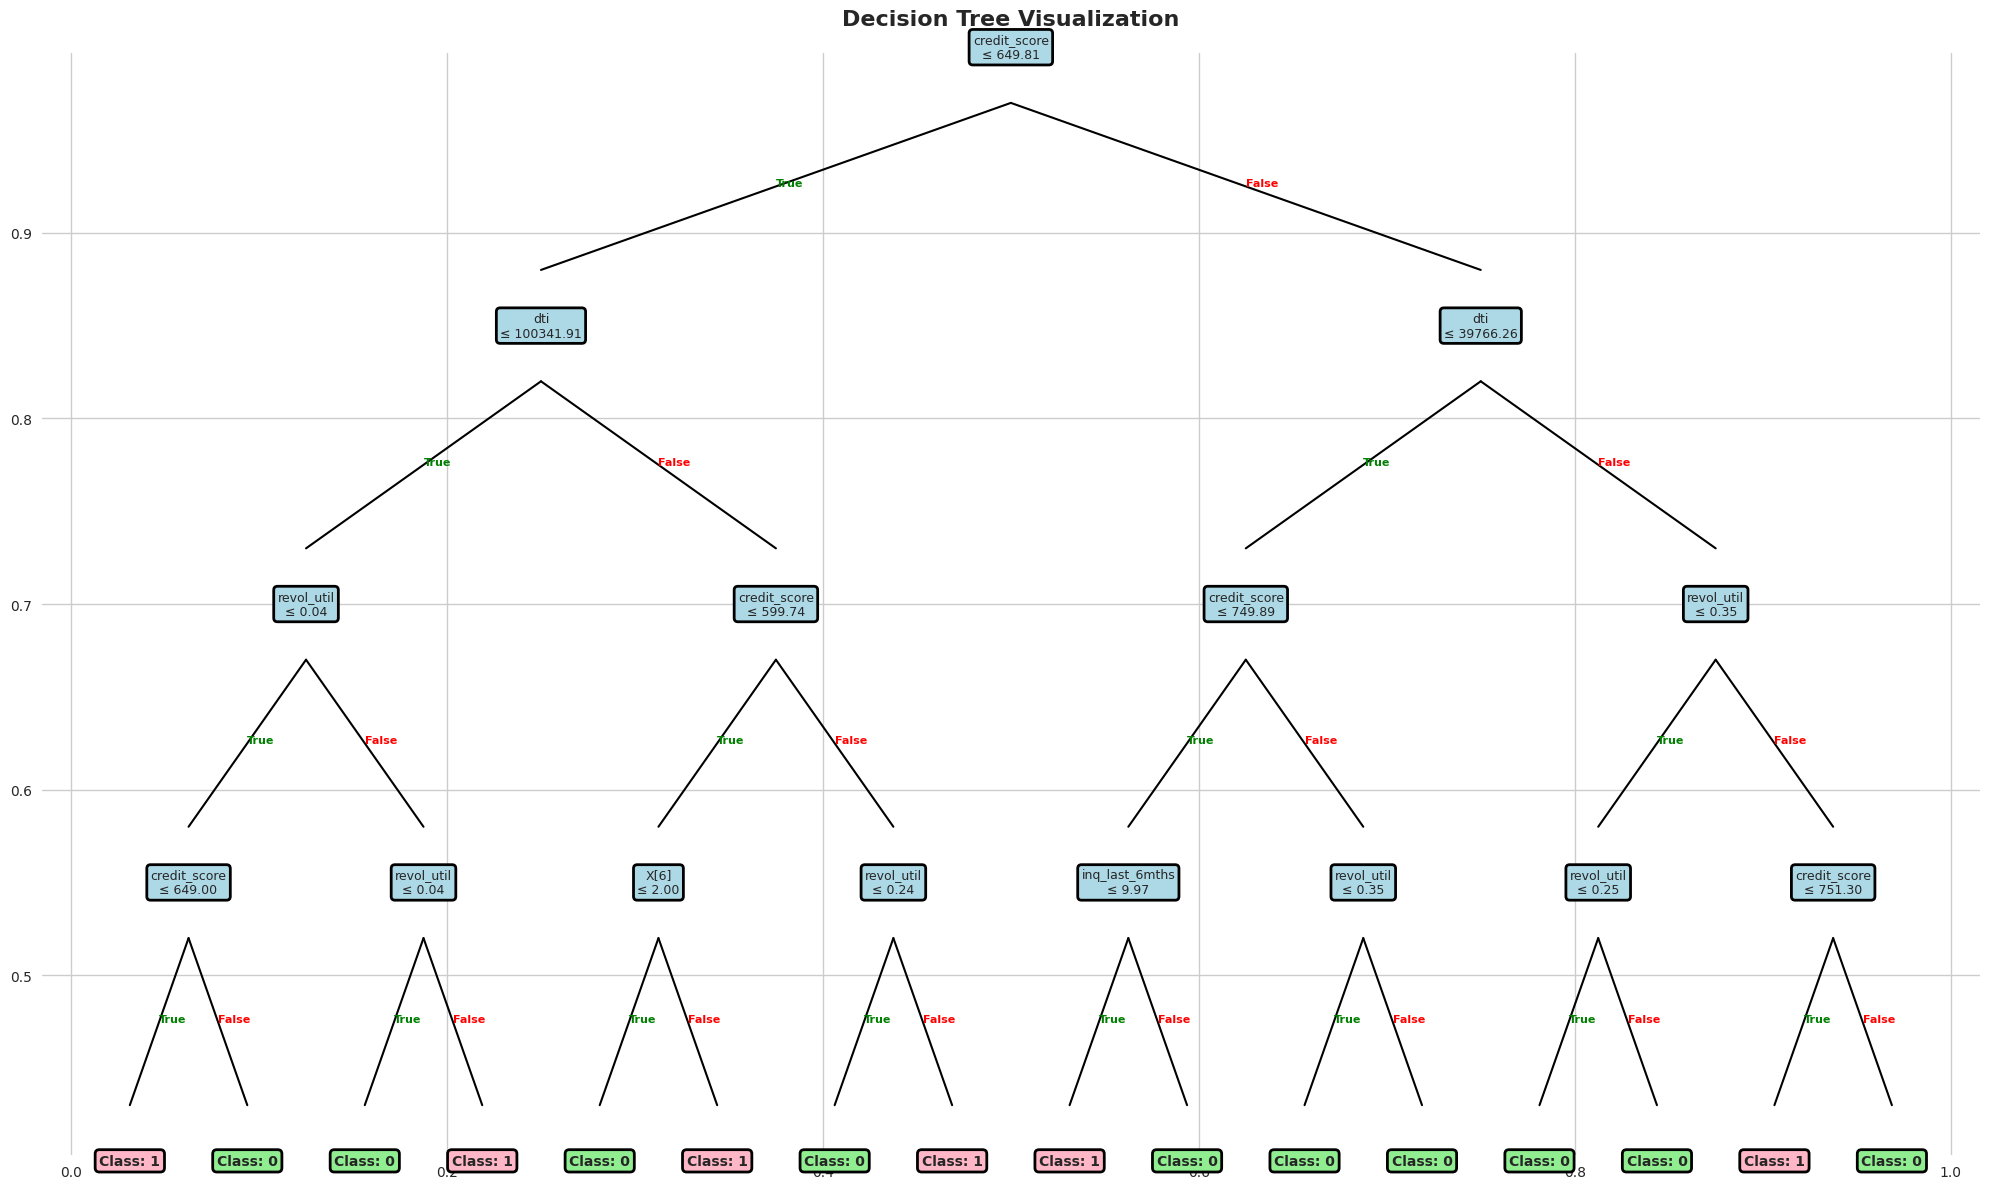

In [46]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_tree_visual(node, feature_names=None, ax=None, x=0.5, y=1.0,
                     dx=0.25, dy=0.15, depth=0, max_depth=5):
    """Visualizes the decision tree using matplotlib."""
    if node is None or depth > max_depth:
        return

    if ax is None:
        fig, ax = plt.subplots(figsize=(16, 10))
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis('off')

    if node.is_leaf():
        # Leaf node - show prediction
        color = '#90EE90' if node.prediction == 0 else '#FFB6C6'
        bbox = dict(boxstyle="round,pad=0.3", facecolor=color, edgecolor='black', linewidth=2)
        ax.text(x, y, f'Class: {node.prediction}',
                ha='center', va='center', fontsize=10, bbox=bbox, weight='bold')
    else:
        # Decision node - show split
        if feature_names and 0 <= node.feature < len(feature_names):
            feature_name = feature_names[node.feature]
        else:
            feature_name = f"X[{node.feature}]"

        label = f'{feature_name}\n≤ {node.threshold:.2f}'
        bbox = dict(boxstyle="round,pad=0.3", facecolor='#ADD8E6', edgecolor='black', linewidth=2)
        ax.text(x, y, label, ha='center', va='center', fontsize=9, bbox=bbox)

        # Calculate positions for children
        new_dx = dx / 2
        left_x = x - dx
        right_x = x + dx
        child_y = y - dy

        # Draw edges
        if node.left:
            ax.plot([x, left_x], [y - 0.03, child_y + 0.03], 'k-', linewidth=1.5)
            ax.text((x + left_x) / 2, (y + child_y) / 2, 'True',
                   fontsize=8, color='green', weight='bold')
            plot_tree_visual(node.left, feature_names, ax, left_x, child_y,
                           new_dx, dy, depth + 1, max_depth)

        if node.right:
            ax.plot([x, right_x], [y - 0.03, child_y + 0.03], 'k-', linewidth=1.5)
            ax.text((x + right_x) / 2, (y + child_y) / 2, 'False',
                   fontsize=8, color='red', weight='bold')
            plot_tree_visual(node.right, feature_names, ax, right_x, child_y,
                            new_dx, dy, depth + 1, max_depth)

    return ax

# Usage:
feature_names = ['credit_score', 'dti', 'annual_income', 'revol_util', 'inq_last_6mths', 'emp_length']
fig, ax = plt.subplots(figsize=(20, 12))
plot_tree_visual(custom_tree, feature_names, ax=ax, max_depth=4)  # Adjust max_depth as needed
plt.title('Decision Tree Visualization', fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.show()

### Bias-Variance Decomposition

After fine-tuning, your Random Forest should have a higher test accuracy than the best single tree. In general, the model is not just memorizing the training data but is learning the underlying patterns that apply to new, unseen data.

However, the best-performing model consistently achieves a maximum test accuracy of approximately 90%.

The bias-variance decomposition states that Total Error = Bias² + Variance + Irreducible Error. Our tuning process found a Random Forest model with a test accuracy of ~90%, which appears to be the performance limit for this dataset. Explain this ceiling by identifying which of the three error components is the primary limiting factor and connecting it to the way our dataset's labels were generated.



### Put your answer here:
--------------------------------------------------------------------------
--------------------------------------------------------------------------
--------------------------------------------------------------------------
When we created the data set we added a 10% noise factor in there here:

# Re-introduce controlled noise for a more realistic problem
noise_level = 0.10
n_labels_to_flip = int(noise_level * n_samples)
flip_indices = np.random.choice(df.index, size=n_labels_to_flip, replace=False)
df.loc[flip_indices, 'default'] = 1 - df.loc[flip_indices, 'default']

because of this the total error = irreducible error = 10%.

We reduced Bias since RF is complex enough, We aren't overfitting too much and have controlled it (see test error is higher than train error) but we can not get rid of the 10% error we've added in the beginning

--------------------------------------------------------------------------
--------------------------------------------------------------------------
--------------------------------------------------------------------------

###Conclusion for the Shallow Decision Tree (Part 1)

High Interpretability, Limited Power: A single shallow decision tree is very easy to understand. However, its performance is limited. It captures the most obvious patterns in the data but struggles with more complex relationships.

Sensitivity and High Variance: The structure of a single decision tree is highly sensitive to the specific training data it sees. If you increase the max_depth, it will overfit and you will see high training accuracy but low test accuracy.

###Conclusion for the Random Forest (Part 2)

The Power of Ensembling: The Random Forest will much likely outperform the single best-tuned decision tree. By training many trees on different random subsets of data and features, and then averaging their predictions (majority vote), the model becomes much more powerful and robust.


### Gradescope Submission: Download the .py and .ipynb files and submit!